<a href="https://colab.research.google.com/github/tacyataide/Revisao/blob/tacyataide-patch-1/Detec%C3%A7%C3%A3o_de_bordas_usando_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

In [3]:
uploaded = files.upload()

nome_imagem = list(uploaded.keys())[0]

img = cv2.imread(nome_imagem)

Saving input_image-1.jpg to input_image-1 (1).jpg


Imagem original

Antes de realizar qualquer alteração, exibimos a imagem original.

Essa imagem servirá como referência para comparar os resultados das etapas seguintes do processamento.

Imagem Original


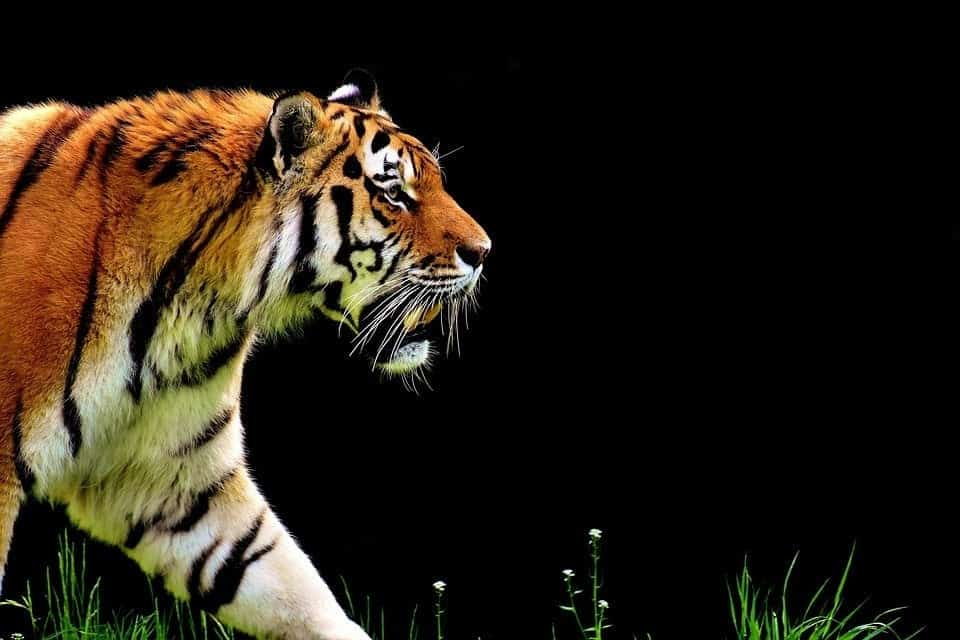

In [4]:
print("Imagem Original")
cv2_imshow(img)

Conversão para tons de cinza

A imagem original possui informações de cor nos canais azul, verde e vermelho.

Para a detecção de bordas, essas informações de cor não são necessárias. O mais importante é analisar as mudanças de intensidade entre os pixels.

Por isso, a imagem é convertida para tons de cinza usando `cv2.cvtColor()`.

Após essa transformação, cada pixel passa a representar apenas um nível de intensidade.

Imagem em Tons de Cinza


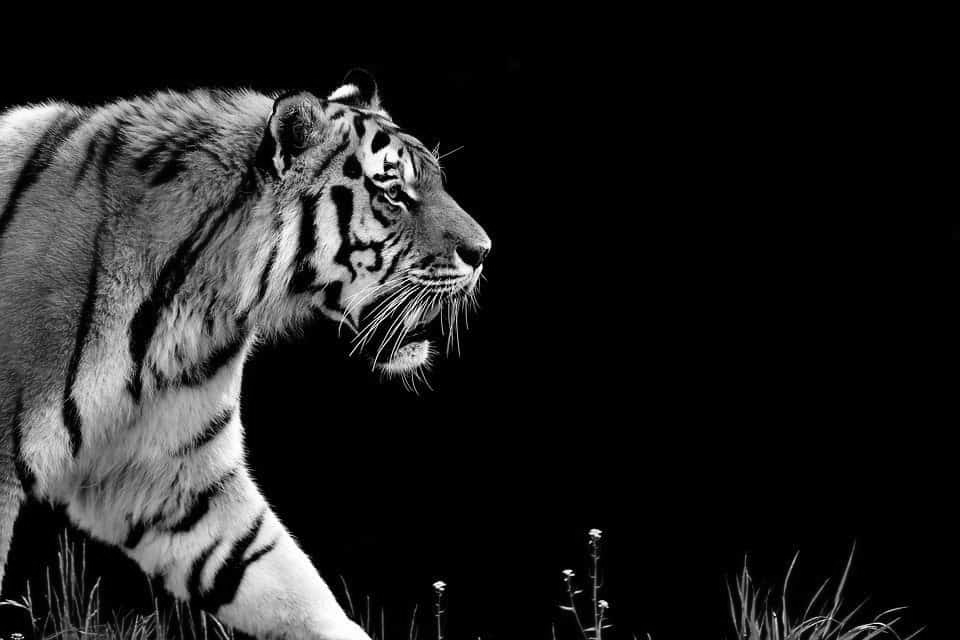

In [5]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Imagem em Tons de Cinza")
cv2_imshow(img_gray)

Aplicação do Gaussian Blur

Após converter a imagem para tons de cinza, aplicamos uma suavização utilizando o filtro Gaussiano.

O objetivo dessa etapa é reduzir pequenos ruídos presentes na imagem.

Esses ruídos poderiam ser interpretados pelos algoritmos como bordas, gerando detecções indesejadas.

Neste exemplo, utilizamos um kernel de tamanho `3 × 3`.

Imagem com Gaussian Blur


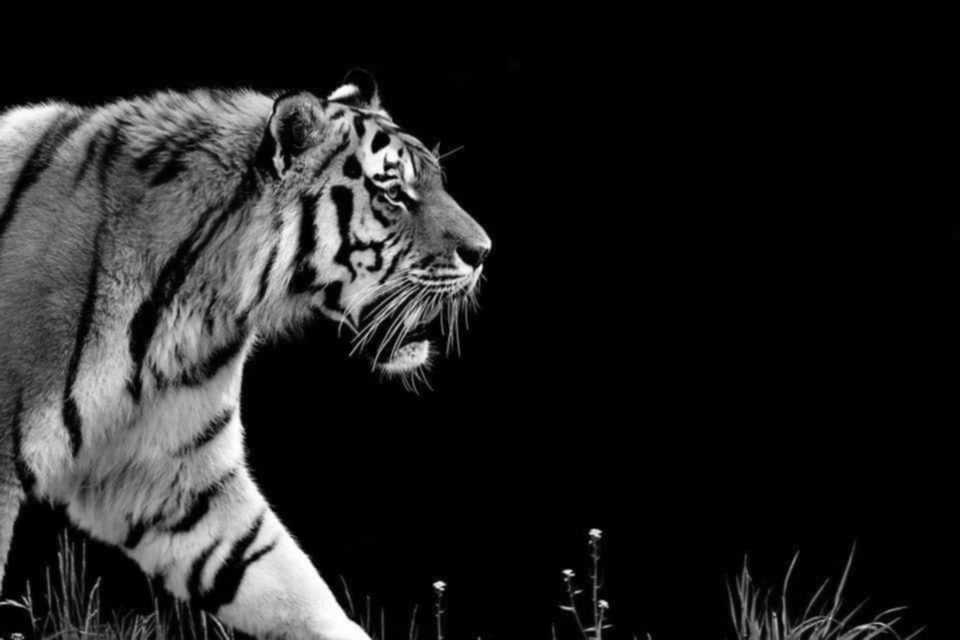

In [6]:
img_blur = cv2.GaussianBlur(img_gray, (3, 3), 0)

print("Imagem com Gaussian Blur")
cv2_imshow(img_blur)

Sobel na direção X

Agora aplicamos o operador de Sobel na direção X.

Essa operação calcula a variação da intensidade dos pixels no eixo horizontal.

Para isso, utilizamos:

`dx = 1`

`dy = 0`

O resultado tende a destacar principalmente as bordas verticais presentes na imagem.

Sobel X


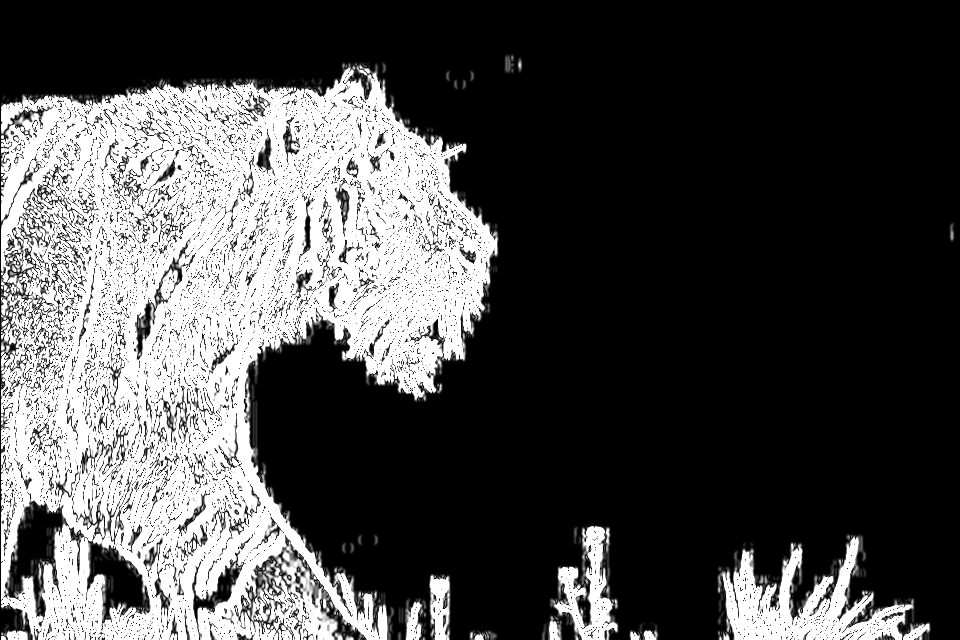

In [7]:
sobelx = cv2.Sobel(
    src=img_blur,
    ddepth=cv2.CV_32F,
    dx=1,
    dy=0,
    ksize=5
)

sobelx_display = cv2.convertScaleAbs(sobelx)

print("Sobel X")
cv2_imshow(sobelx_display)

Sobel na direção Y

Em seguida, aplicamos o operador de Sobel na direção Y.

Nesse caso, são utilizados:

`dx = 0`

`dy = 1`

Essa configuração calcula a variação da intensidade dos pixels na direção vertical.

O resultado tende a destacar principalmente as bordas horizontais da imagem.

Sobel Y


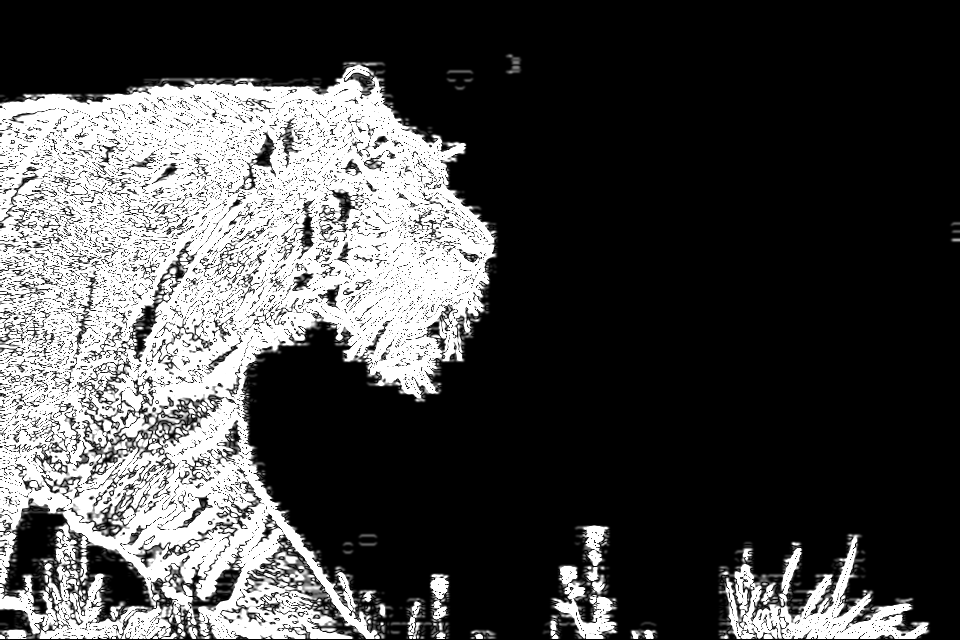

In [8]:
sobely = cv2.Sobel(
    src=img_blur,
    ddepth=cv2.CV_32F,
    dx=0,
    dy=1,
    ksize=5
)

sobely_display = cv2.convertScaleAbs(sobely)

print("Sobel Y")
cv2_imshow(sobely_display)

 Magnitude do gradiente de Sobel

Até agora analisamos as bordas separadamente nas direções X e Y.

Para obter uma representação combinada das bordas, calculamos a magnitude do gradiente.

Essa magnitude utiliza os resultados do Sobel X e Sobel Y.

Matematicamente:

\[
G = \sqrt{G_x^2 + G_y^2}
\]

onde:

- \(G_x\) representa o gradiente na direção X;
- \(G_y\) representa o gradiente na direção Y;
- \(G\) representa a intensidade total da borda.

Assim, conseguimos destacar bordas independentemente de sua orientação.

Magnitude do Gradiente Sobel


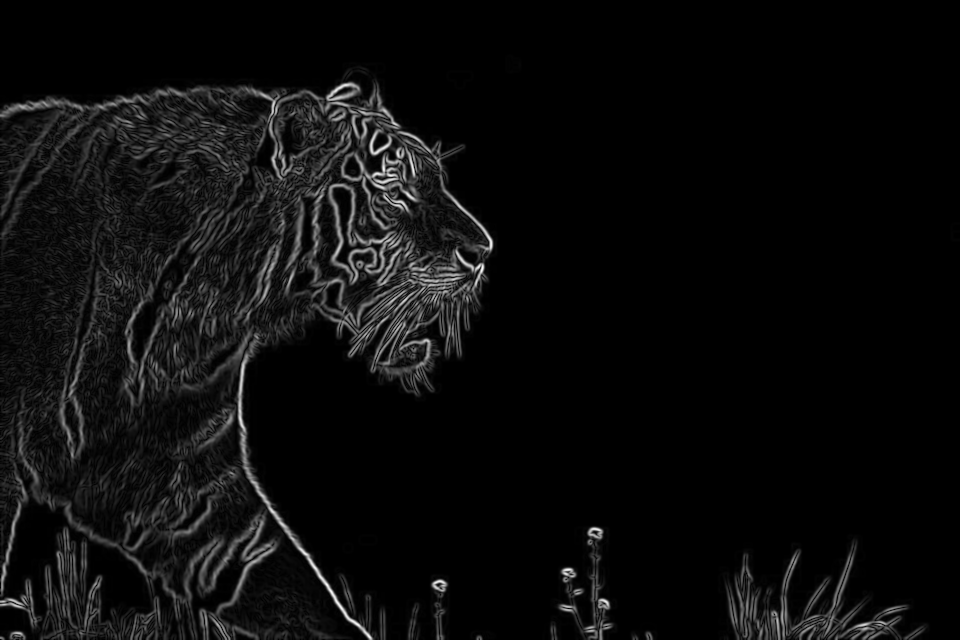

In [9]:
sobelxy = cv2.magnitude(sobelx, sobely)

sobelxy_display = cv2.normalize(
    sobelxy,
    None,
    0,
    255,
    cv2.NORM_MINMAX,
    dtype=cv2.CV_8U
)

print("Magnitude do Gradiente Sobel")
cv2_imshow(sobelxy_display)

Detecção de bordas com Canny

Por fim, aplicamos o detector de bordas de Canny.

O Canny utiliza dois valores de limiar para decidir quais variações de intensidade devem ser consideradas bordas.

Neste exemplo são utilizados:

`threshold1 = 100`

`threshold2 = 200`

O resultado é uma imagem binária, em que as bordas detectadas aparecem destacadas em branco e o restante da imagem aparece em preto.

Comparado ao resultado direto do Sobel, o Canny normalmente produz bordas mais finas e bem definidas.

Detecção de Bordas Canny


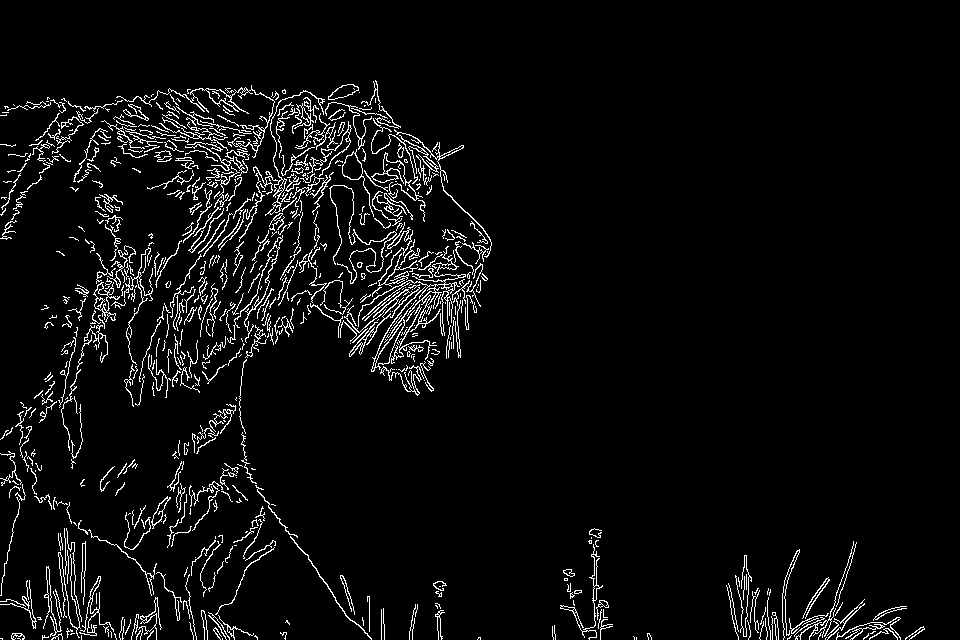

In [10]:
edges = cv2.Canny(
    image=img_blur,
    threshold1=100,
    threshold2=200
)

print("Detecção de Bordas Canny")
cv2_imshow(edges)